# **Tugas 8 : Clustering dengan Fuzzy C-means**

**Nama : Achmad Baharuddin Akbar**

**NIM  : 210411100001**

In [373]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [374]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [375]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,Awas! Kebiasaan Sepele Ini 26 Persen Lebih Tin...,"Rabu, 27 Nov 2024 19:02 WIB",Jakarta - Stroke merupakan salah satu kondisi ...,Kesehatan,Jakarta Stroke merupakan salah satu kondisi m...,jakarta stroke merupakan salah satu kondisi m...,"['jakarta', 'stroke', 'merupakan', 'salah', 's...",jakarta stroke salah kondisi medis menurunkan ...
1,"Berlebihan Makan Petai Bisa Picu Ginjal Rusak,...","Rabu, 27 Nov 2024 18:02 WIB",Jakarta - Petai atau parkia speciosa merupakan...,Kesehatan,Jakarta Petai atau parkia speciosa merupakan ...,jakarta petai atau parkia speciosa merupakan ...,"['jakarta', 'petai', 'atau', 'parkia', 'specio...",jakarta petai parkia speciosa tanaman asia ten...
2,"Pria Tertua di Dunia Meninggal di Usia 112, Su...","Rabu, 27 Nov 2024 16:52 WIB",Jakarta - Pria yang dinobatkan sebagai orang t...,Kesehatan,Jakarta Pria yang dinobatkan sebagai orang te...,jakarta pria yang dinobatkan sebagai orang te...,"['jakarta', 'pria', 'yang', 'dinobatkan', 'seb...",jakarta pria dinobatkan orang tertua dunia ver...
3,"Gejala Wasir (Ambeien), Penyebab, dan Cara Men...","Rabu, 27 Nov 2024 16:47 WIB",Jakarta - Wasir sama dengan ambeien. Keduanya ...,Kesehatan,Jakarta Wasir sama dengan ambeien Keduanya me...,jakarta wasir sama dengan ambeien keduanya me...,"['jakarta', 'wasir', 'sama', 'dengan', 'ambeie...",jakarta wasir ambeien nama penyakit hemoroid p...
4,"Jangan Abaikan Kelelahan, Catat Tips Biar Petu...","Rabu, 27 Nov 2024 16:03 WIB",Jakarta - Kelompok Penyelenggara Pemungutan Su...,Kesehatan,Jakarta Kelompok Penyelenggara Pemungutan Sua...,jakarta kelompok penyelenggara pemungutan sua...,"['jakarta', 'kelompok', 'penyelenggara', 'pemu...",jakarta kelompok penyelenggara pemungutan suar...


In [376]:
texts = df['Filtering/stopword removal']

In [377]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [378]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 4875)

In [379]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 50):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=1.9, max_iter=1000, error=0.001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.576885500926921, ARI=0.11006623001207509, NMI=0.18737851059355315
Iterasi dengan n_components=3: Silhouette=0.3743834384419683, ARI=0.30731969860064584, NMI=0.2930927817293784
Iterasi dengan n_components=4: Silhouette=0.33365961894570206, ARI=0.3543232622980222, NMI=0.372446574610306
Iterasi dengan n_components=5: Silhouette=0.15992672416863132, ARI=0.5732897959183674, NMI=0.47063913471263574
Iterasi dengan n_components=6: Silhouette=0.23511805880065953, ARI=0.48505024049347056, NMI=0.4379889725086195
Iterasi dengan n_components=7: Silhouette=0.23148872411389512, ARI=0.37842534911329506, NMI=0.32885237991265603
Iterasi dengan n_components=8: Silhouette=0.21514287767418389, ARI=0.4572332996116568, NMI=0.4179384484708855
Iterasi dengan n_components=9: Silhouette=0.21093822412945432, ARI=0.4302338386990199, NMI=0.3987144225709687
Iterasi dengan n_components=10: Silhouette=0.2830016598586991, ARI=0.33041840441275394, NMI=0.32874294448038094
Itera

In [383]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.576885500926921
Best ARI is achieved by n_components=5 with score: 0.5732897959183674
Best NMI is achieved by n_components=5 with score: 0.47063913471263574


In [384]:
# Mengurutkan hasil berdasarkan silhouette score (dari tertinggi ke terendah)
sorted_results = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)

# Menampilkan hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")
print("\nAll results (sorted by silhouette score):")
for n, score in sorted_results:
    print(f"n_components={n}: Silhouette Score={score}")


Best n_components: 2 with silhouette score: 0.576885500926921

All results (sorted by silhouette score):
n_components=2: Silhouette Score={'silhouette': 0.576885500926921, 'ari': 0.11006623001207509, 'nmi': 0.18737851059355315}
n_components=3: Silhouette Score={'silhouette': 0.3743834384419683, 'ari': 0.30731969860064584, 'nmi': 0.2930927817293784}
n_components=22: Silhouette Score={'silhouette': 0.3524387842979948, 'ari': 0.04897739504843918, 'nmi': 0.048883288551161835}
n_components=4: Silhouette Score={'silhouette': 0.33365961894570206, 'ari': 0.3543232622980222, 'nmi': 0.372446574610306}
n_components=13: Silhouette Score={'silhouette': 0.31350905081718833, 'ari': 0.2854243339406018, 'nmi': 0.2971734207185139}
n_components=24: Silhouette Score={'silhouette': 0.2910827371822451, 'ari': 0.05855067497276855, 'nmi': 0.05293526690877434}
n_components=21: Silhouette Score={'silhouette': 0.2847417420978388, 'ari': 0.09377345560160559, 'nmi': 0.08198909974765356}
n_components=10: Silhouett

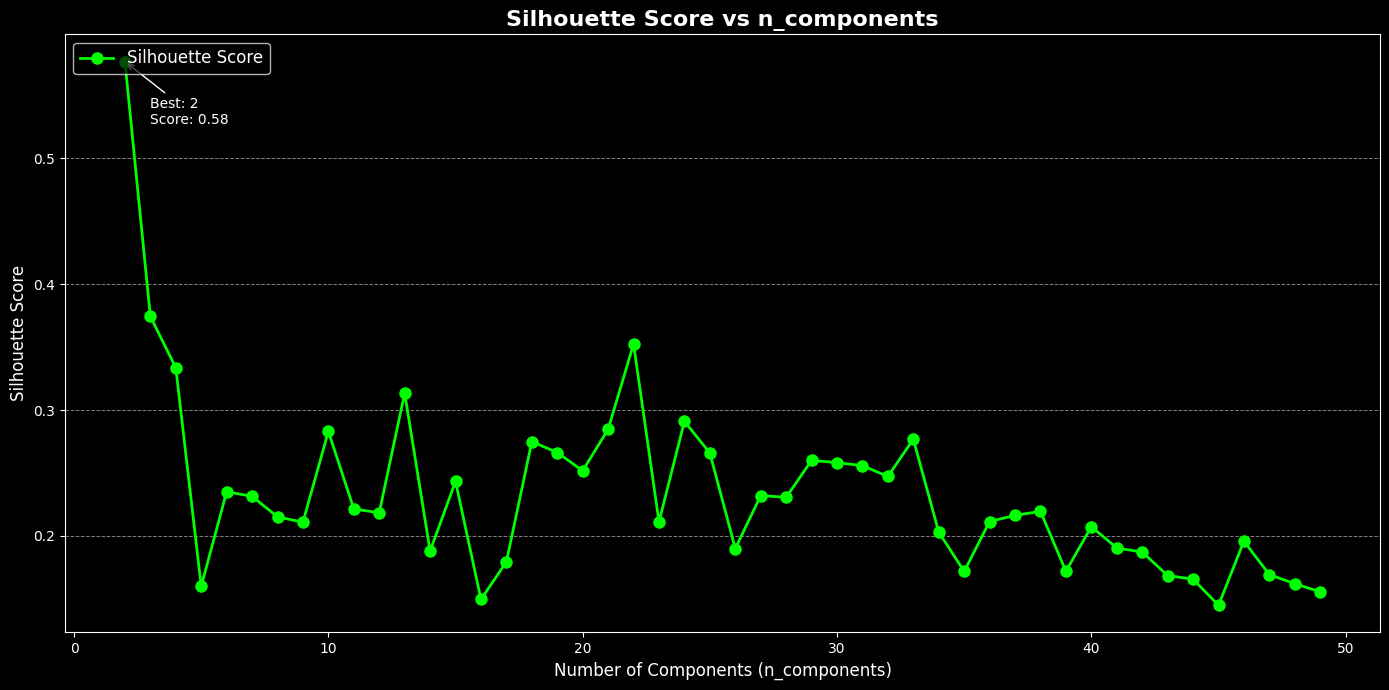

In [385]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Clustering

Silhouette Score: 0.1599
Jumlah data pada setiap cluster:
Cluster
1    50
0    50
Name: count, dtype: int64


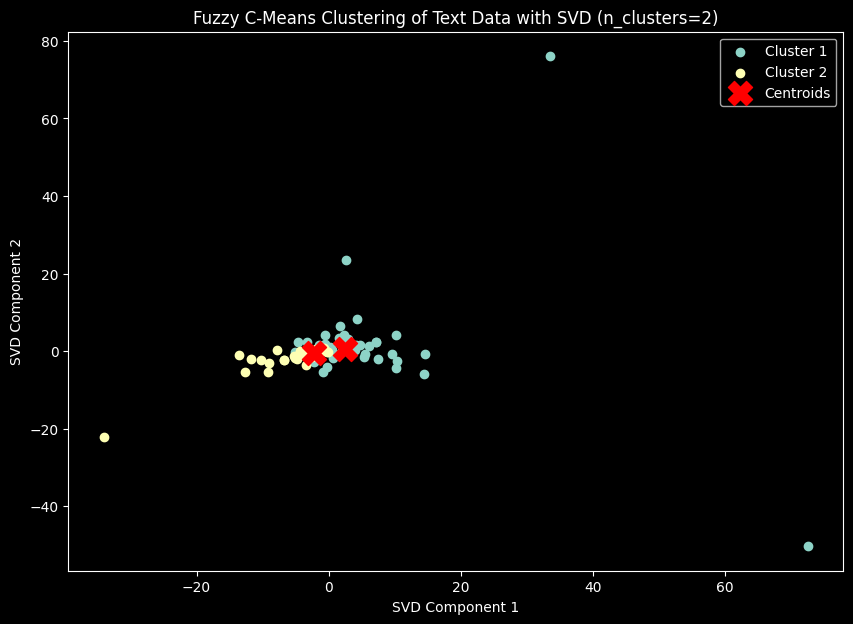

In [405]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv('/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv')
data = df['Filtering/stopword removal']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=5 , random_state=random_seed)
data_cluster = svd.fit_transform(data_normalisasi)



# Fuzzy C-Means Clustering
n_clusters = 2  # Ganti sesuai kebutuhan
fcm = FCM(n_clusters=n_clusters, m=1.9, max_iter=1000, epsilon=0.001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 0],
                data_cluster[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:,0], cluster_centers[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [406]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal,Cluster
0,Awas! Kebiasaan Sepele Ini 26 Persen Lebih Tin...,"Rabu, 27 Nov 2024 19:02 WIB",Jakarta - Stroke merupakan salah satu kondisi ...,Kesehatan,Jakarta Stroke merupakan salah satu kondisi m...,jakarta stroke merupakan salah satu kondisi m...,"['jakarta', 'stroke', 'merupakan', 'salah', 's...",jakarta stroke salah kondisi medis menurunkan ...,1
1,"Berlebihan Makan Petai Bisa Picu Ginjal Rusak,...","Rabu, 27 Nov 2024 18:02 WIB",Jakarta - Petai atau parkia speciosa merupakan...,Kesehatan,Jakarta Petai atau parkia speciosa merupakan ...,jakarta petai atau parkia speciosa merupakan ...,"['jakarta', 'petai', 'atau', 'parkia', 'specio...",jakarta petai parkia speciosa tanaman asia ten...,1
2,"Pria Tertua di Dunia Meninggal di Usia 112, Su...","Rabu, 27 Nov 2024 16:52 WIB",Jakarta - Pria yang dinobatkan sebagai orang t...,Kesehatan,Jakarta Pria yang dinobatkan sebagai orang te...,jakarta pria yang dinobatkan sebagai orang te...,"['jakarta', 'pria', 'yang', 'dinobatkan', 'seb...",jakarta pria dinobatkan orang tertua dunia ver...,1
3,"Gejala Wasir (Ambeien), Penyebab, dan Cara Men...","Rabu, 27 Nov 2024 16:47 WIB",Jakarta - Wasir sama dengan ambeien. Keduanya ...,Kesehatan,Jakarta Wasir sama dengan ambeien Keduanya me...,jakarta wasir sama dengan ambeien keduanya me...,"['jakarta', 'wasir', 'sama', 'dengan', 'ambeie...",jakarta wasir ambeien nama penyakit hemoroid p...,1
4,"Jangan Abaikan Kelelahan, Catat Tips Biar Petu...","Rabu, 27 Nov 2024 16:03 WIB",Jakarta - Kelompok Penyelenggara Pemungutan Su...,Kesehatan,Jakarta Kelompok Penyelenggara Pemungutan Sua...,jakarta kelompok penyelenggara pemungutan sua...,"['jakarta', 'kelompok', 'penyelenggara', 'pemu...",jakarta kelompok penyelenggara pemungutan suar...,1
...,...,...,...,...,...,...,...,...,...
95,Pop Mart Tindak Penjual Makanan Labubu hingga ...,"Selasa, 26 Nov 2024 09:30 WIB",Jakarta - Pop Mart akan menindak tegas para pe...,Kuliner,Jakarta Pop Mart akan menindak tegas para pen...,jakarta pop mart akan menindak tegas para pen...,"['jakarta', 'pop', 'mart', 'akan', 'menindak',...",jakarta pop mart menindak penjual makanan paka...,0
96,"3 Resep Ayam Kecap Pedas, Lauk Rumahan yang En...","Selasa, 26 Nov 2024 09:00 WIB",Tentang Bahan Langkah Jakarta - Ayam yang dima...,Kuliner,Tentang Bahan Langkah Jakarta Ayam yang dimas...,tentang bahan langkah jakarta ayam yang dimas...,"['tentang', 'bahan', 'langkah', 'jakarta', 'ay...",bahan langkah jakarta ayam dimasak kecap manis...,0
97,Ngeunah! Nasi Liwet Ayam Goreng dan Ikan Peda ...,"Selasa, 26 Nov 2024 08:30 WIB",Jakarta - Ngeunah! Nasi Liwet Ayam Goreng dan ...,Kuliner,Jakarta Ngeunah Nasi Liwet Ayam Goreng dan Ik...,jakarta ngeunah nasi liwet ayam goreng dan ik...,"['jakarta', 'ngeunah', 'nasi', 'liwet', 'ayam'...",jakarta ngeunah nasi liwet ayam goreng ikan pe...,0
98,Konsumsi 5 Jenis Rempah Ini Ampuh Bakar Lemak ...,"Selasa, 26 Nov 2024 08:00 WIB",Jakarta - Lemak yang menumpuk di perut tidak h...,Kuliner,Jakarta Lemak yang menumpuk di perut tidak ha...,jakarta lemak yang menumpuk di perut tidak ha...,"['jakarta', 'lemak', 'yang', 'menumpuk', 'di',...",jakarta lemak menumpuk perut mengganggu penamp...,1


In [407]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori_encoded, dan Cluster
selected_columns = df[['id', 'kategori', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

print(len(cluster_0))
print(len(cluster_1))

    id   kategori  Cluster
0    0  Kesehatan        1
1    1  Kesehatan        1
2    2  Kesehatan        1
3    3  Kesehatan        1
4    4  Kesehatan        1
..  ..        ...      ...
95  95    Kuliner        0
96  96    Kuliner        0
97  97    Kuliner        0
98  98    Kuliner        1
99  99    Kuliner        0

[100 rows x 3 columns]
Anggota Cluster 0: [10, 11, 13, 26, 32, 45, 50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 75, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 96, 97, 99]
Anggota Cluster 1: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 51, 72, 74, 84, 93, 98]
50
50


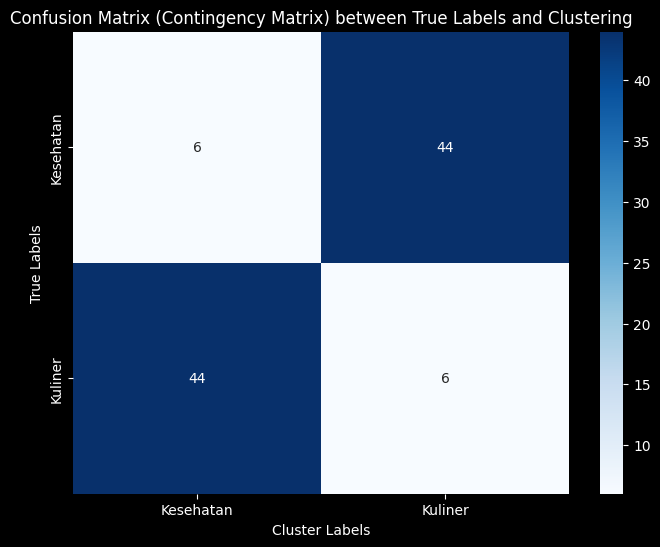

Confusion Matrix (Contingency Matrix):
[[ 6 44]
 [44  6]]


In [410]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [411]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.1599


In [419]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import joblib
import pandas as pd

# Membaca data
df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
data = df['Filtering/stopword removal'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM dalam pipeline
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,         # Jumlah cluster yang diinginkan
        m=1.9,                # Fuzziness coefficient
        max_iter=1000,        # Maksimal iterasi
        epsilon=0.001,        # Toleransi konvergensi
        random_state=42       # Menetapkan seed untuk random state
    )
    fcm.fit(X)
    return fcm

# Fungsi pembungkus untuk FCM (untuk FunctionTransformer)
def fit_fcm_wrapper(X):
    return fit_fcm(X)

# Tuning parameter TfidfVectorizer
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))),
    ('scaler', StandardScaler(with_mean=False)),
    ('svd', TruncatedSVD(n_components=20)),
    ('fcm', FunctionTransformer(func=fit_fcm_wrapper))
])

# Fit pipeline pada data pelatihan
pipeline.fit(data)

# Simpan pipeline yang telah dilatih
joblib.dump(pipeline, 'svd_tfidf_scaler_fcm_pipeline.pkl')

['svd_tfidf_scaler_fcm_pipeline.pkl']

In [421]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import numpy as np
import pandas as pd

# 1. Memuat pipeline yang sudah dilatih sebelumnya
pipeline = joblib.load('svd_tfidf_scaler_fcm_pipeline.pkl')

# 2. Melakukan FCM pada data pelatihan
# Misalnya, kita memiliki data pelatihan yang dilabeli sebagai berikut:
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv')  # Ganti dengan path data pelatihan Anda
data_pelatihan = df['Filtering/stopword removal']  # Kolom yang berisi teks

# Transformasi data pelatihan menggunakan pipeline
X_train_transformed = pipeline[:-1].transform(data_pelatihan)  # Tanpa FCM, hanya TF-IDF, Scaling, dan SVD
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

# 3. Melakukan clustering FCM pada data pelatihan
fcm_model = FCM(n_clusters=2, m=1.9, max_iter=1000, epsilon=0.001, random_state=42)
fcm_model.fit(X_train_transformed)

# 4. Menyelaraskan cluster dengan label yang diketahui (Kesehatan = 0, Kuliner = 1)
# Misalnya, jika label pada data pelatihan adalah:
labels_train = df['kategori']

# Menyelaraskan cluster dengan label
cluster_labels = fcm_model.predict(X_train_transformed)

cluster_to_label = {0: 'Kesehatan', 1: 'Kuliner'}

# Menyelaraskan prediksi cluster dengan label
predicted_labels = [cluster_to_label[cluster] for cluster in cluster_labels]

# 5. Memuat data baru untuk prediksi
teks_baru = """
Jakarta - Penyakit diabetes dapat memengaruhi banyak bagian tubuh, salah satunya kulit. Beberapa perubahan pada kulit bisa menunjukkan kadar gula darah seseorang yang tinggi.
Dikutip dari American Academy of Dermatology Association (AAD), munculnya perubahan pada kulit ini tidak boleh disepelekan. Hal tersebut bisa menunjukkan adanya kondisi diabetes atau pradiabetes yang tidak terdiagnosis, sehingga membutuhkan perawatan yang cepat dan tepat.
Lantas, apa saja tanda-tanda peringatan diabetes yang dapat muncul di kulit?
Bintik-bintik Gelap di Tulang Kering
Shin spot atau diabetic dermopathy merupakan salah satu efek gula darah tinggi pada kulit. Shin spot ini memiliki ciri berupa bintik-bintik gelap yang kadang bisa juga tampak seperti garis. Kondisi ini umumnya muncul di tulang kering.
Tidak seperti bintik-bintik penuaan, bintik-bintik ini sering kali mulai memudar setelah diabetes terkontrol dengan baik, biasanya dalam waktu 18 hingga 24 bulan. Kondisi ini dapat bertahan di kulit tanpa batas waktu.
Kulit Keras dan Menebal
Mereka yang memiliki diabetes umumnya akan ditandai dengan kulit yang keras, tebal, dan tampak bengkak. Nama medis dari kondisi ini adalah scleredema diabeticorum.
Kondisi ini seringkali terjadi di punggung bagian atas, kulit menebal dan mengencang secara perlahan selama berbulan-bulan atau bertahun-tahun. Kondisi ini juga dapat terjadi di bahu, leher, atau di tempat lain, tetapi tidak pernah terjadi di tangan atau kaki.
Luka Sulit Sembuh
Mereka yang memiliki kadar gula darah (glukosa) tinggi dalam jangka waktu lama dapat menyebabkan sirkulasi darah yang buruk dan kerusakan saraf. Hal ini membuat tubuh sulit untuk menyembuhkan luka, terutama pada kaki.
Benjolan seperti Jerawat Meradang
Kondisi diabetes yang tidak terkendali dapat menyebabkan kadar trigliserida menjadi sangat tinggi. Jika hal itu terjadi, tubuh dapat mengembangkan kondisi kulit yang disebut xanthomatosis erupsi.
Kondisi ini menyebabkan benjolan kecil berwarna kuning kemerahan pada bagian belakang tangan, kaki, lengan, kaki, dan bokong.
Benjolan Kuning di Sekitar Kelopak Mata
Benjolan dan bercak ini terbentuk saat kadar lemak dalam darah Anda tinggi, yang dapat menjadi tanda bahwa seseorang memiliki diabetes yang tidak terkontrol dengan baik. Nama medis untuk kondisi ini adalah xanthelasma. Benjolan dan bercak ini berwarna kekuningan atau jingga kekuningan.
Kutil pada Kulit
Skin tag atau kutil kulit bisa menjadi salah satu tanda dari seseorang yang mengidap diabetes, meskipun tidak selalu demikian. Kulit kulit bisa menjadi tanda diabetes karena berkaitan dengan resistensi insulin.
Selain itu, obesitas yang dikaitkan dengan diabetes juga bisa menjadi faktor penyebab skin tag. Biasanya, pertumbuhan kutil yang paling sering terjadi pada kelopak mata, leher, ketiak, dan selangkangan.
"""

# Transformasi data baru menggunakan pipeline
X_new_transformed = pipeline[:-1].transform([teks_baru])
if hasattr(X_new_transformed, 'toarray'):
    X_new_transformed = X_new_transformed.toarray()

# 6. Prediksi cluster untuk data baru
cluster_new = fcm_model.predict(X_new_transformed)

# Menyelaraskan prediksi cluster dengan label
predicted_label_new = cluster_to_label[cluster_new[0]]

# 7. Menampilkan hasil
print(f"Teks baru ini diprediksi ke dalam cluster: {predicted_label_new}")


Teks baru ini diprediksi ke dalam cluster: Kesehatan
